In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
import glob
from pyprojroot import here

In [2]:
RAW_DATA_DIR = here() / "data" / "raw"
INTERIM_DATA_DIR = here() / "data" / "interim"
PROCESSED_DATA_DIR = here() / "data" / "processed"
RESULTS_DATA_DIR = here() / "results"

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR/"crime_count_2015-2025.csv", encoding="latin-1")

<Figure size 1000x500 with 0 Axes>

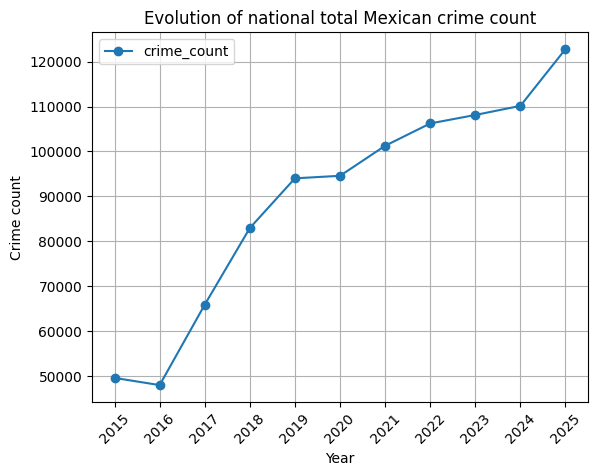

In [4]:
yearly_crime_rates = df.groupby('year')[['crime_count']].sum()
plt.figure(figsize=(10, 5))
yearly_crime_rates.plot(y='crime_count', kind='line', marker='o')
plt.title('Evolution of national total Mexican crime count')
plt.xlabel('Year')
plt.ylabel('Crime count')
plt.xticks(yearly_crime_rates.index)
plt.grid(True)
plt.xticks(rotation=45)
plt.savefig(RESULTS_DATA_DIR/'raw_descriptive_analysis/crime_count_evolution.png') 
plt.show()

<Figure size 1000x500 with 0 Axes>

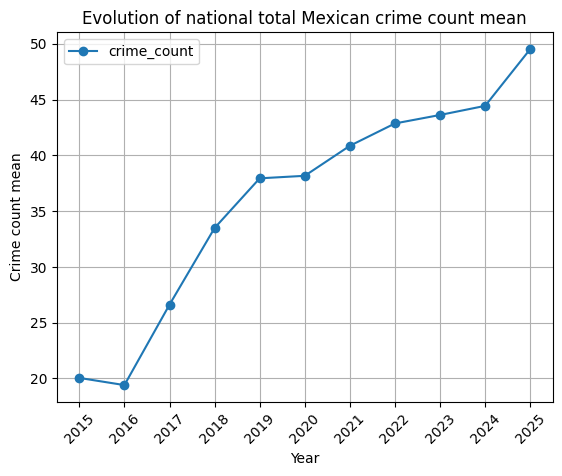

In [5]:
yearly_crime_rates = df.groupby('year')[['crime_count']].mean()
plt.figure(figsize=(10, 5))
yearly_crime_rates.plot(y='crime_count', kind='line', marker='o')
plt.title('Evolution of national total Mexican crime count mean')
plt.xlabel('Year')
plt.ylabel('Crime count mean')
plt.xticks(yearly_crime_rates.index)
plt.grid(True)
plt.xticks(rotation=45)
plt.savefig(RESULTS_DATA_DIR/'raw_descriptive_analysis/crime_mean_evolution.png') 
plt.show()

### Crime counts per year dataframe dictionary

In [6]:
crime_count_dict = dict.fromkeys(df['year'].unique().astype(int).tolist())
df['year'] = df['year'].astype(int)
for name, _ in crime_count_dict.items():
    dfyear = df[df['year'] == name].fillna(0).copy()
    crime_count_dict[name] = dfyear

### Histograms per year

In [7]:
def histogram(dataframe, year=int):
    plt.figure(figsize=(8, 5))
    plt.hist(dataframe['crime_count'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    
    plt.title(f'{year} Distribution of Crime Counts per Municipality', fontsize=14, fontweight='bold')
    plt.xlabel('Crime Count', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig(RESULTS_DATA_DIR/f'raw_descriptive_analysis/{year}_crimerate_hist.png') 

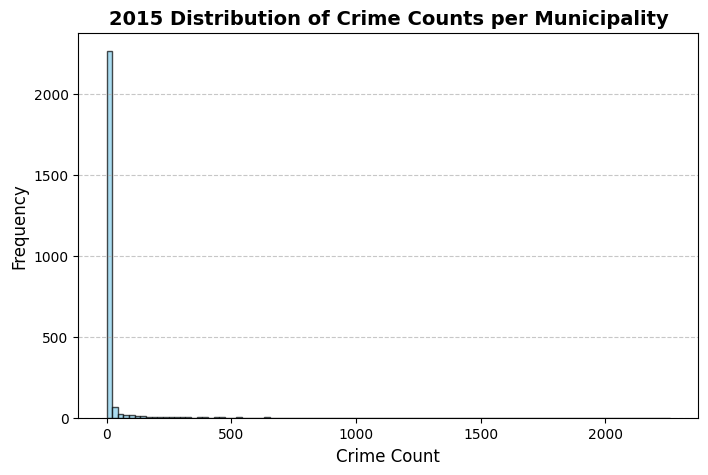

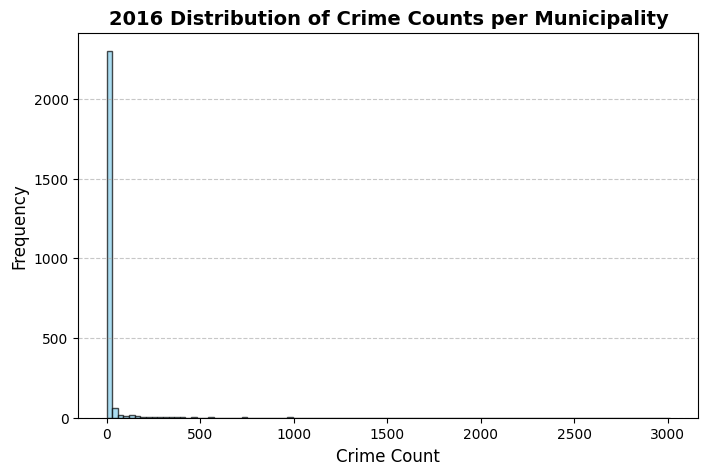

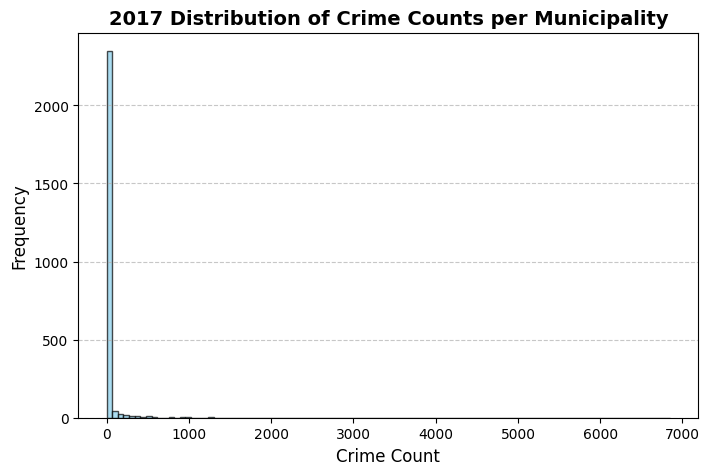

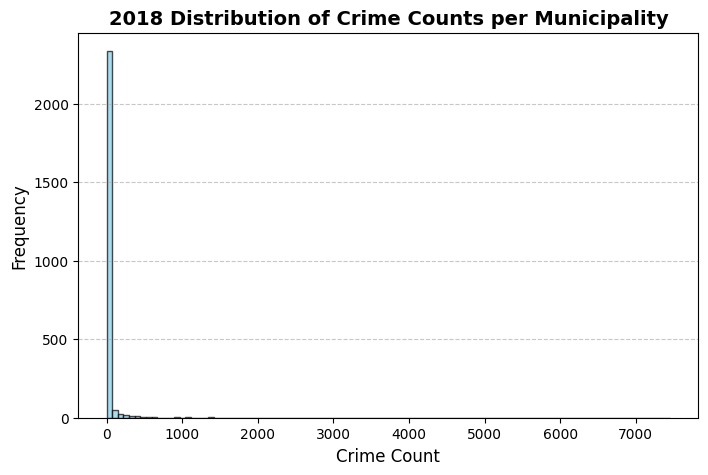

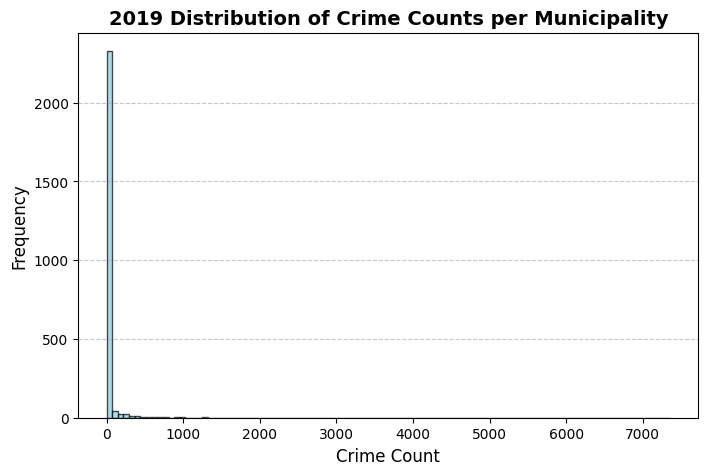

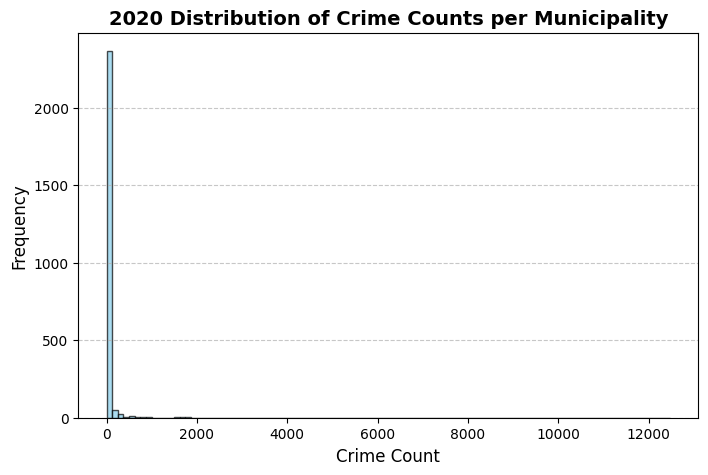

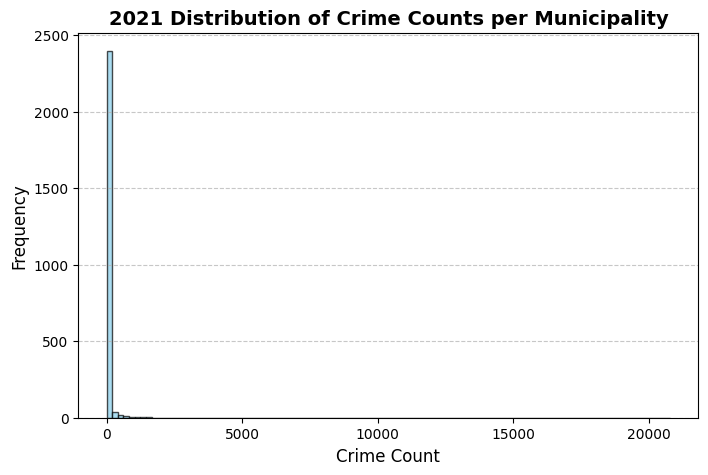

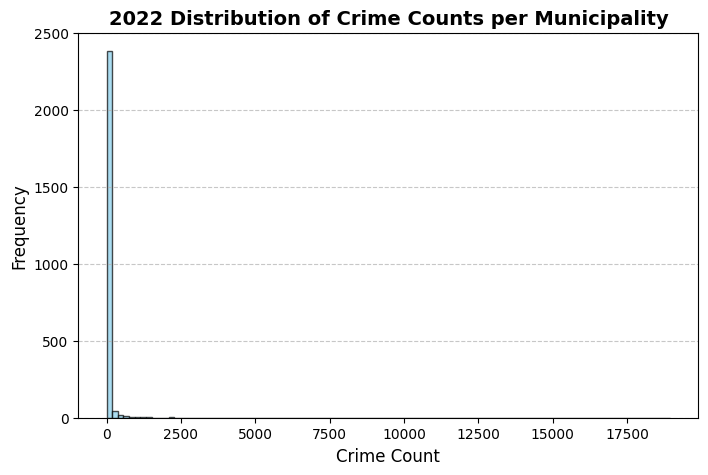

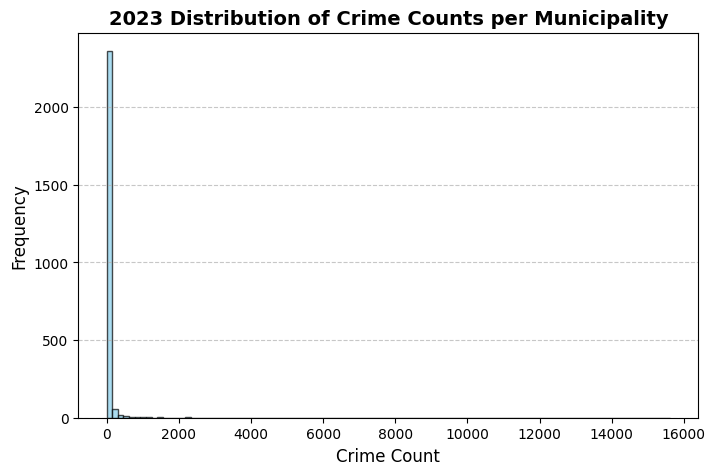

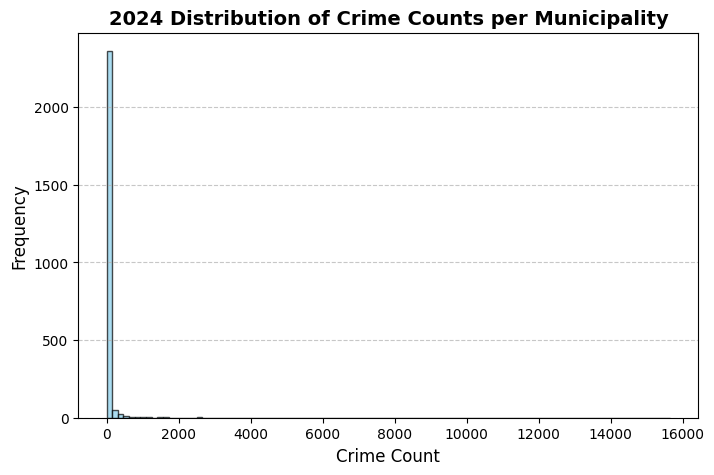

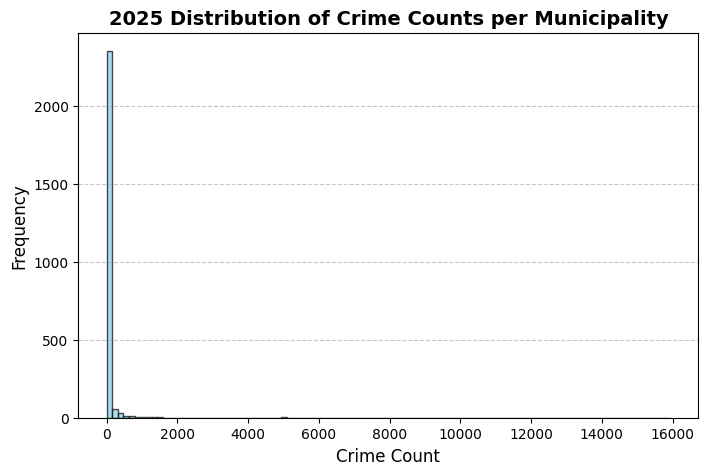

In [8]:
for name, values in crime_count_dict.items():
    histogram(values, name)

In [9]:
out_dir = RESULTS_DATA_DIR / "raw_descriptive_analysis"
gif_path = RESULTS_DATA_DIR / "raw_descriptive_analysis" / "crimecount_hist_animation.gif"

frame_paths = sorted(
    glob.glob(f"{out_dir}/*_crimerate_hist.png"),
    key=lambda p: int(p.split("_crimerate_hist.png")[0].split("/")[-1].split("\\")[-1])
)

frames = [Image.open(p).convert("RGB") for p in frame_paths]

frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=1000,      # ms per frame
    loop=0,             # loop forever
)

print(f"Saved GIF with {len(frames)} frames to {gif_path}")

Saved GIF with 11 frames to C:\Users\franc\OneDrive\Documents\Repositories\organized-crime-prediction\results\raw_descriptive_analysis\crimecount_hist_animation.gif


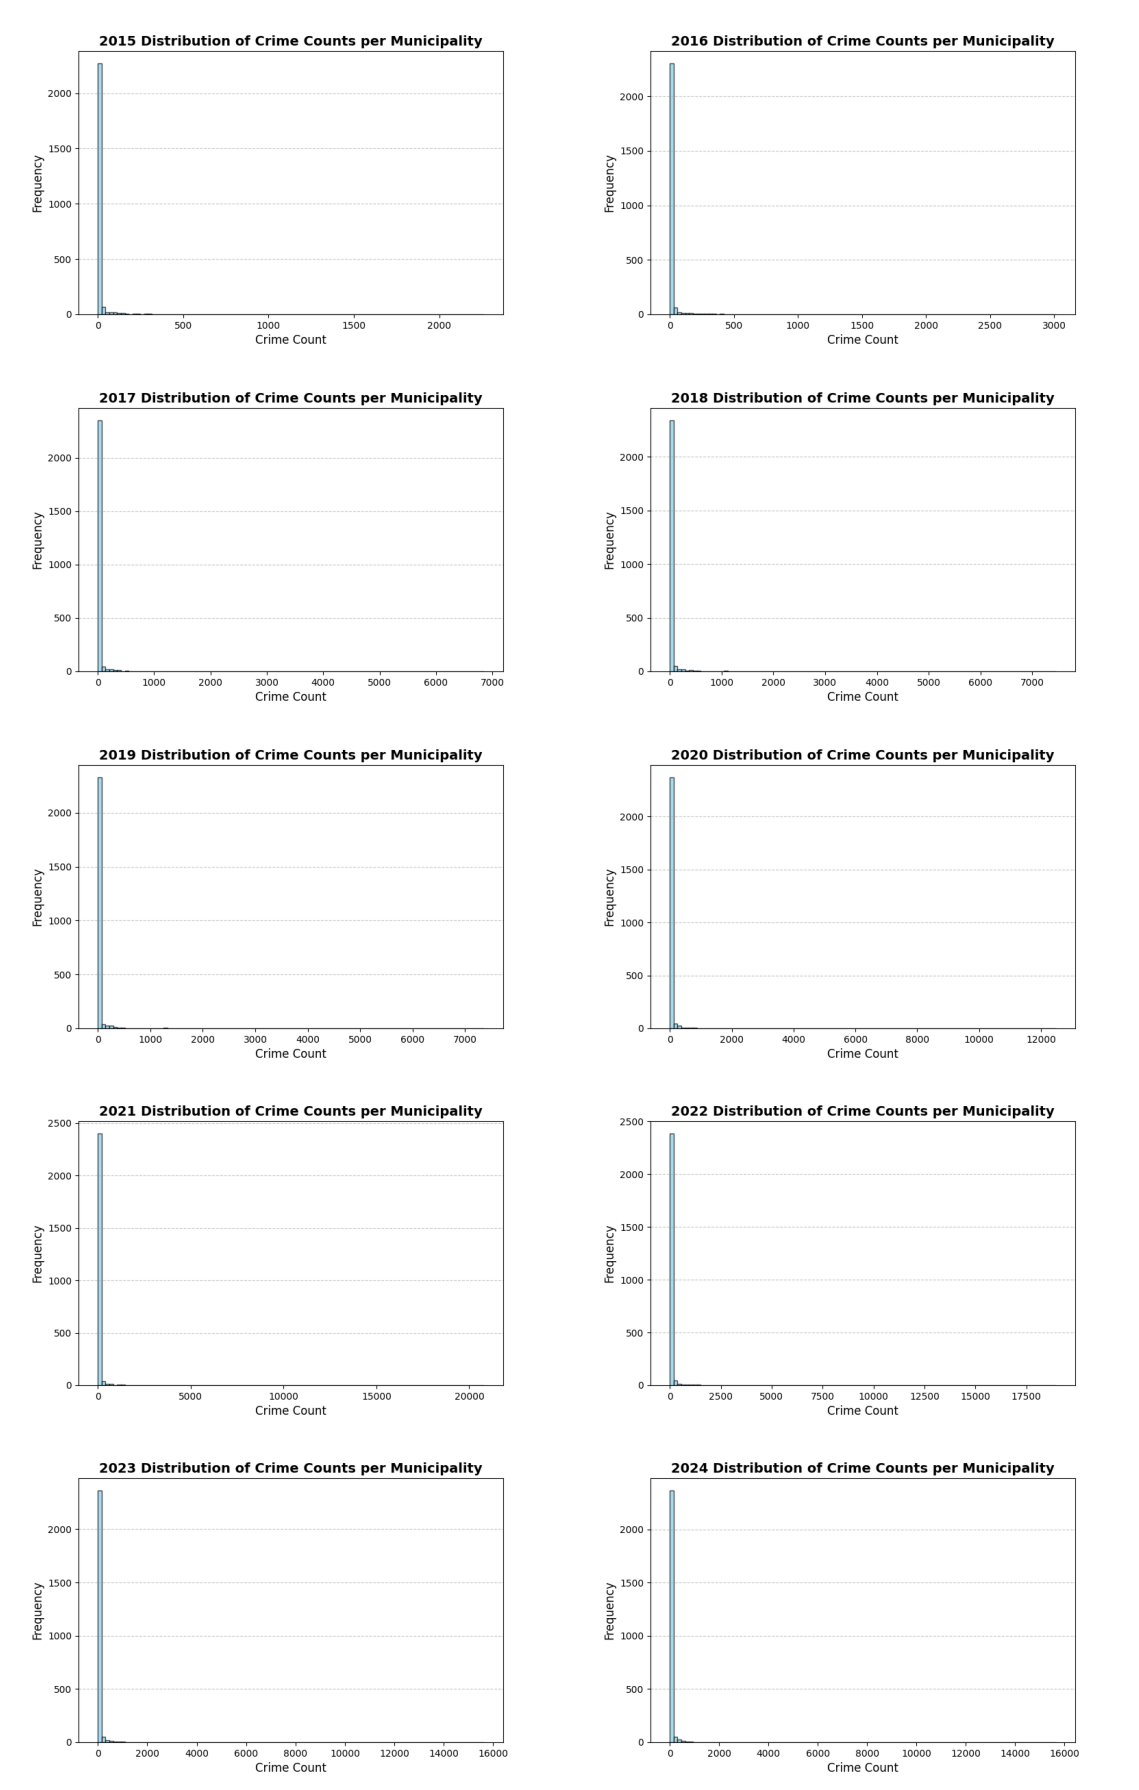

In [10]:
image_paths = [
    RESULTS_DATA_DIR/f'raw_descriptive_analysis/2015_crimerate_hist.png', RESULTS_DATA_DIR/f'raw_descriptive_analysis/2016_crimerate_hist.png',
    RESULTS_DATA_DIR/f'raw_descriptive_analysis/2017_crimerate_hist.png', RESULTS_DATA_DIR/f'raw_descriptive_analysis/2018_crimerate_hist.png',
    RESULTS_DATA_DIR/f'raw_descriptive_analysis/2019_crimerate_hist.png', RESULTS_DATA_DIR/f'raw_descriptive_analysis/2020_crimerate_hist.png',
    RESULTS_DATA_DIR/f'raw_descriptive_analysis/2021_crimerate_hist.png', RESULTS_DATA_DIR/f'raw_descriptive_analysis/2022_crimerate_hist.png',
    RESULTS_DATA_DIR/f'raw_descriptive_analysis/2023_crimerate_hist.png', RESULTS_DATA_DIR/f'raw_descriptive_analysis/2024_crimerate_hist.png'
]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))
axes_flat = axes.flatten()

for i, img_path in enumerate(image_paths):
    ax = axes_flat[i]
    
    img = mpimg.imread(img_path)
    ax.imshow(img)
    
    ax.axis('off') 

plt.tight_layout()
plt.savefig(RESULTS_DATA_DIR/f'raw_descriptive_analysis/2015-2024_crime_counts_histograms.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

### Summary per year

In [11]:
summary_dfs = dict.fromkeys(df['year'].unique().astype(int).tolist())
for name, value in crime_count_dict.items():
    summary_dfs[name] = value['crime_count'].agg([
        'min', 'max', 'mean', 'median', 'std', 'skew', 'kurt', 'sum',
    ]).to_frame().T
    summary_dfs[name]['cero'] = (value['crime_count'] == 0).sum()
    summary_dfs[name]['observations'] = len(value['crime_count'])

combined_summary_df = pd.concat(summary_dfs.values(), keys=summary_dfs.keys())

In [12]:
combined_summary_df.to_csv(RESULTS_DATA_DIR/f"raw_descriptive_analysis/data_descriptive_summary.csv")

In [13]:
combined_summary_df

,,min,max,mean,median,std,skew,kurt,sum,cero,observations
2015,crime_count,0.0,2261.0,20.048830,0.0,117.897866,11.757302,170.389778,49681.0,1322,2478
2016,crime_count,0.0,3013.0,19.405569,0.0,120.974821,14.664237,285.434831,48087.0,1335,2478
2017,crime_count,0.0,6851.0,26.619451,0.0,213.593563,21.703882,588.180011,65963.0,1253,2478
2018,crime_count,0.0,7457.0,33.494754,1.0,262.350600,19.401169,466.098048,83000.0,1208,2478
2019,crime_count,0.0,7359.0,37.949153,1.0,288.722679,18.829346,428.737253,94038.0,1098,2478
2020,crime_count,0.0,12480.0,38.175141,1.0,361.265987,25.259558,748.637331,94598.0,1113,2478
2021,crime_count,0.0,20787.0,40.866828,1.0,468.548508,36.855718,1573.077108,101268.0,1082,2478
2022,crime_count,0.0,18950.0,42.871671,1.0,441.075876,34.389488,1400.863294,106236.0,1037,2478
2023,crime_count,0.0,15622.0,43.630751,1.0,386.892884,29.665641,1105.808487,108117.0,1046,2478
2024,crime_count,0.0,15648.0,44.448345,1.0,384.380359,29.435463,1118.485750,110143.0,1093,2478


### Boxplots

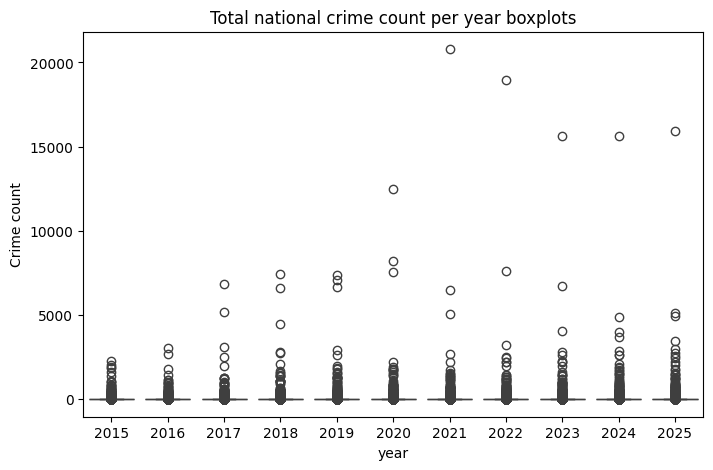

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='year', y='crime_count')
plt.ylabel("Crime count")
plt.title('Total national crime count per year boxplots')
plt.savefig(RESULTS_DATA_DIR/f'raw_descriptive_analysis/full_boxplots.png') 
plt.show()
plt.close()

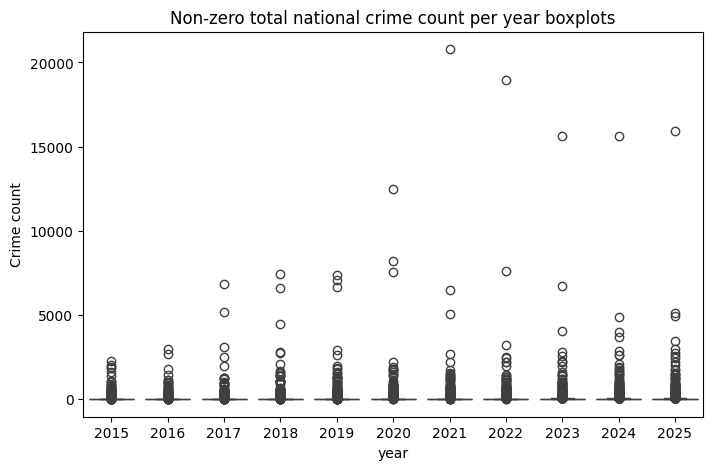

In [15]:
non_zero_df = df[df['crime_count'] > 0].copy()
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_df, x='year', y='crime_count')
plt.ylabel("Crime count")
plt.title('Non-zero total national crime count per year boxplots')
plt.savefig(RESULTS_DATA_DIR/f'raw_descriptive_analysis/NZ_boxplots.png') 
plt.show()
plt.close()

###  Top 1%-5% concentration analysis

In [16]:
concentration_results = []

for year, df in crime_count_dict.items():
    df_sorted = df.sort_values('crime_count', ascending=False).reset_index(drop=True)
    total = df_sorted['crime_count'].sum()
    n = len(df_sorted)
    
    top1_n = max(1, int(np.ceil(n * 0.01)))
    top5_n = max(1, int(np.ceil(n * 0.05)))
    
    top1_sum = df_sorted.loc[:top1_n-1, 'crime_count'].sum()
    top5_sum = df_sorted.loc[:top5_n-1, 'crime_count'].sum()
    
    concentration_results.append({
        'year': year,
        'total': total,
        'top1_n_municipalities': top1_n,
        'top1_share': top1_sum / total if total > 0 else np.nan,
        'top5_n_municipalities': top5_n,
        'top5_share': top5_sum / total if total > 0 else np.nan,
        'max_municipality_share': df_sorted.loc[0, 'crime_count'] / total if total > 0 else np.nan
    })

concentration_df = pd.DataFrame(concentration_results).sort_values('year')
concentration_df.to_csv(RESULTS_DATA_DIR/"raw_descriptive_analysis/concentration.csv")
print(concentration_df.to_string(index=False))

 year  total  top1_n_municipalities  top1_share  top5_n_municipalities  top5_share  max_municipality_share
 2015  49681                     25    0.492240                    124    0.846299                0.045510
 2016  48087                     25    0.495373                    124    0.844511                0.062657
 2017  65963                     25    0.550839                    124    0.857011                0.103861
 2018  83000                     25    0.571337                    124    0.863855                0.089843
 2019  94038                     25    0.557658                    124    0.857175                0.078256
 2020  94598                     25    0.584262                    124    0.854046                0.131927
 2021 101268                     25    0.584183                    124    0.852540                0.205267
 2022 106236                     25    0.562239                    124    0.843029                0.178376
 2023 108117                     25  

In [17]:
top10_by_year = {}

for year, df in crime_count_dict.items():
    df_sorted = df.sort_values('crime_count', ascending=False).reset_index(drop=True)
    top10_by_year[year] = df_sorted.loc[:9, ['CVEGEO', 'crime_count']].assign(rank=range(1, 11))

# Combine into one long dataframe for inspection
top10_long = pd.concat(
    [df.assign(year=year) for year, df in top10_by_year.items()],
    ignore_index=True
)
top10_wide = top10_long.pivot(index='rank', columns='year', values='CVEGEO')
top10_wide.to_csv(RESULTS_DATA_DIR/"raw_descriptive_analysis/concentration_top10.csv")
print(top10_wide)

year   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024  \
rank                                                                         
1     21114   8037   8037  11020  11020  11020  11020  11020  11020  11020   
2     11020  11020  11020   8037   8037   2004   2004   2004   2004   2004   
3      8037   8019   2004   2004   2004   8037   8037   8037  24028  24028   
4     14039   9015   2002   2002   2002   5030   5030   5030   8037   8037   
5     14120  14039   9015   9015   9015   1001  19039   5035  19026  19026   
6      8019   2002   9014   9007   9007   2002   9015   1001   5035   5035   
7      9015   2004   9007   9014   5030   5035   5035  19039   5030  26030   
8     14098   9014   8019   1001   1001   9015  15057  21114  19039  19039   
9     26030  19039  19039   9005   5035   9007  26030  26030  26030   5030   
10     1001  22014  22014   5030   9014  19039   2002   9015   1001   9015   

year   2025  
rank         
1     11020  
2      2004  
3     2

In [18]:
all_top10_ids = pd.concat([df['CVEGEO'] for df in top10_by_year.values()])
appearance_counts = all_top10_ids.value_counts()
print(f"\nDistinct municipalities that appeared in top 10 at least once: {len(appearance_counts)}")
print(f"Municipalities appearing in top 10 in ALL 11 years:\n{appearance_counts[appearance_counts == 11]}")
print(f"\nFull appearance count distribution:\n{appearance_counts}")


Distinct municipalities that appeared in top 10 at least once: 23
Municipalities appearing in top 10 in ALL 11 years:
CVEGEO
11020    11
8037     11
Name: count, dtype: int64

Full appearance count distribution:
CVEGEO
11020    11
8037     11
9015     10
2004     10
19039     8
5035      7
1001      7
5030      7
26030     6
2002      6
9014      4
9007      4
24028     3
8019      3
21114     2
19026     2
14039     2
22014     2
14120     1
14098     1
9005      1
15057     1
24035     1
Name: count, dtype: int64
